In [2]:
!pip install PyWavelets

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: C:\Users\andre\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: C:\Users\andre\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: C:\Users\andre\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
!pip install scipy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: C:\Users\andre\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import pandas as pd
import pywt
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
from scipy.signal import welch

In [8]:
rr = pd.read_csv("../1_f.csv", header=None).values.flatten().astype(float)
print(f"intervals: {len(rr)}, avg: {rr.mean():.1f}")

intervals: 300, avg: 744.8


In [9]:
## Interpolation

In [51]:
D = 4.0
t_rr = np.cumsum(rr) / 1000.0
t_rr = t_rr - t_rr[0]
t_u  = np.arange(0, t_rr[-1], 1.0 / D)
sig  = interp1d(t_rr, rr, kind='cubic', fill_value='extrapolate')(t_u)
sig_centered = sig - np.mean(sig)

print(f"sig: {len(sig)}, time: {t_u[-1]:.1f} sec")

sig: 891, time: 222.5 sec


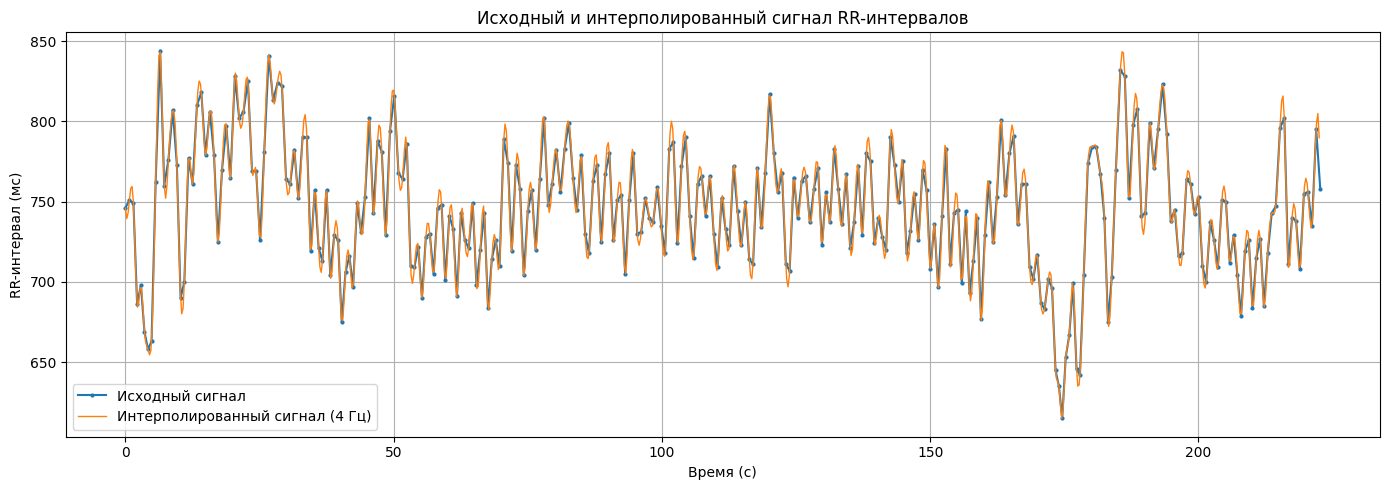

In [52]:
plt.figure(figsize=(14, 5))
plt.plot(t_rr, rr, 'o-', label='Исходный сигнал', markersize=2)
plt.plot(t_u, sig, '-', label='Интерполированный сигнал (4 Гц)', linewidth=1)
plt.xlabel('Время (с)')
plt.ylabel('RR-интервал (мс)')
plt.title('Исходный и интерполированный сигнал RR-интервалов')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [54]:
def compute_cwt(signal, wavelet, f_low, f_high, fs, n_scales=100):
    fc = pywt.central_frequency(wavelet)
    a_high = fc / (fs * f_low)
    a_low  = fc / (fs * f_high)
    scales = np.exp(np.linspace(np.log(a_low), np.log(a_high), n_scales))
    freqs  = fc / (fs * scales)
    cwt_matrix, _ = pywt.cwt(signal, scales, wavelet, sampling_period=1.0/fs)
    return cwt_matrix, freqs, scales


In [ ]:
def get_wavelets(signal, w, f1, f2, D):
    fc = pywt.central_frequency(w)
    a1 = fc / (D * f1)
    a2 = fc / (D * f2)
    lna1 = np.log(a1)
    lna2 = np.log(a2)
    ln_a = np.linspace(lna1, lna2, 500)
    A = np.exp(ln_a)
    F = fc / (D * A)
    dA = np.zeros(A.shape)
    dA = np.diff(A)
    dA = dA.tolist()
    dA.append(dA[-1])
    cwt_matrix, frq = pywt.cwt(signal - np.mean(signal), A, w)
    icwt_matrix = np.transpose(np.multiply(np.transpose(cwt_matrix), dA / pow(A, 1.5)))
    return cwt_matrix, icwt_matrix, F

In [12]:
# 1-2

In [ ]:
WAVELET = "gaus5"   # basis
F_LOW, F_HIGH = 0.003, 0.4

cwt_matrix, freqs, scales = compute_cwt(sig_centered, WAVELET, F_LOW, F_HIGH, D)

# save in csv
df_cwt = pd.DataFrame(cwt_matrix, index=np.round(scales, 5))
df_cwt.to_csv("cwt_matrix.csv")

C:\Users\andre\AppData\Local\Temp\ipykernel_15324\435608803.py:2: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(t_u, freqs, np.abs(cwt_matrix), cmap='jet', shading='auto')


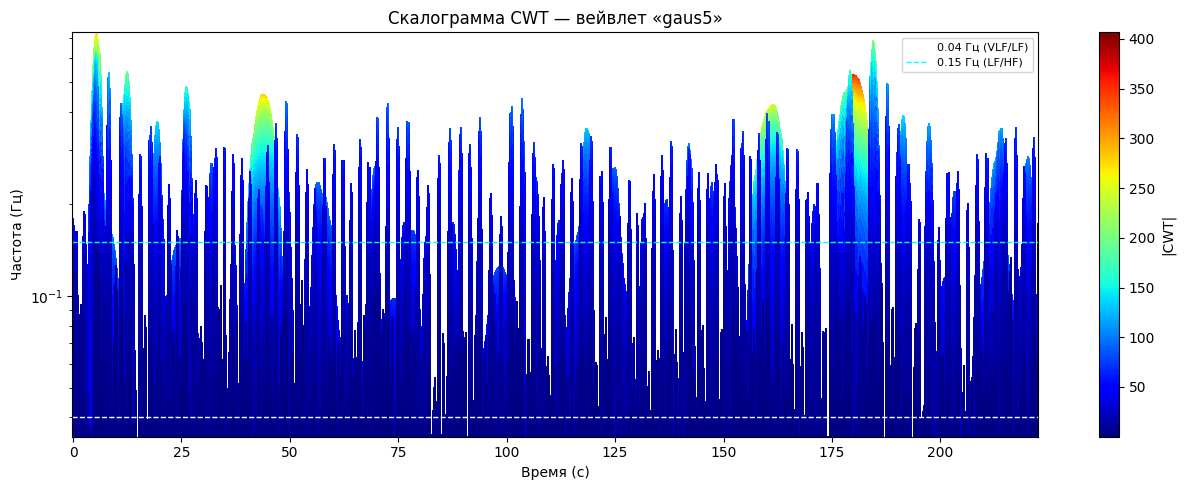

In [ ]:
plt.figure(figsize=(13, 5))
plt.pcolormesh(t_u, freqs, np.abs(cwt_matrix), cmap='jet', shading='auto')
plt.colorbar(label='|CWT|')
plt.yscale('log')
plt.axhline(0.04,  color='white', lw=1, ls='--', label='0.04 Гц (VLF/LF)')
plt.axhline(0.15,  color='cyan',  lw=1, ls='--', label='0.15 Гц (LF/HF)')
plt.legend(loc='upper right', fontsize=8)
plt.xlabel("Время (с)")
plt.ylabel("Частота (Гц)")
plt.title(f"Скалограмма CWT — вейвлет «{WAVELET}»")
plt.tight_layout()
plt.show()

In [15]:
# 3

In [16]:
def band_reconstruct(cwt_matrix, scales, freqs, f1, f2):

    idx = np.where((freqs >= f1) & (freqs < f2))[0]
    if len(idx) == 0:
        return np.zeros(cwt_matrix.shape[1])
    sub = cwt_matrix[idx, :]
    da  = np.diff(scales[idx])
    da  = np.append(da, da[-1])
    # нормировка по масштабу (формула обратного CWT)
    weights = da / scales[idx] ** 1.5
    reconstructed = np.real(np.dot(weights, sub))
    return reconstructed

# Диапазоны согласно стандарту Task Force 1996
HFt  = band_reconstruct(cwt_matrix, scales, freqs, 0.15, 0.40)   # HF
LFt  = band_reconstruct(cwt_matrix, scales, freqs, 0.04, 0.15)   # LF
VLFt = band_reconstruct(cwt_matrix, scales, freqs, 0.003, 0.04)  # VLF
TPt  = HFt + LFt + VLFt

In [17]:
# 4

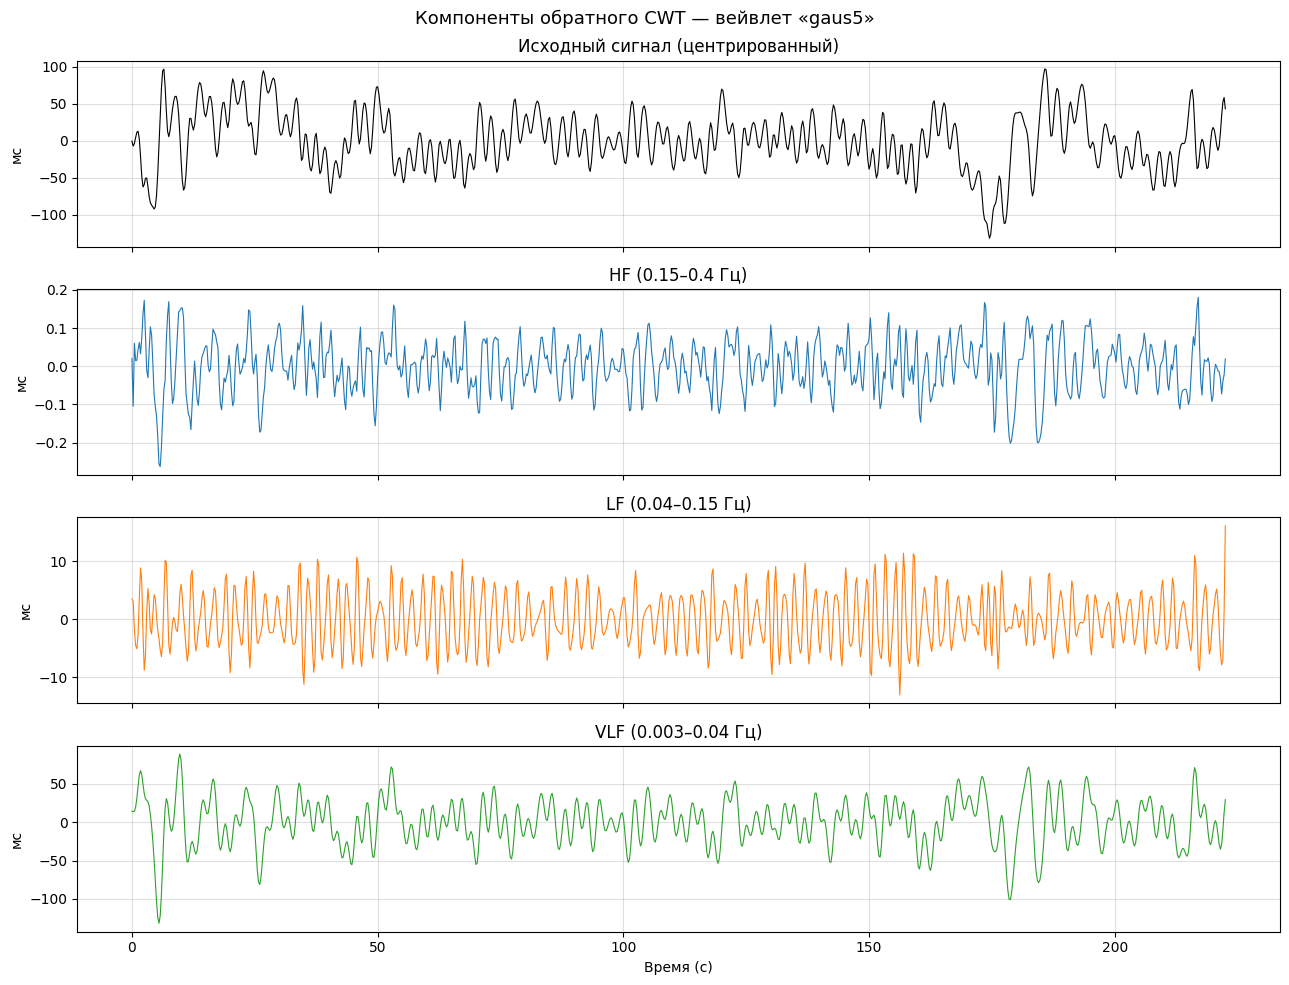

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
data_bands = [(sig_centered, "Исходный сигнал (центрированный)", "black"),
              (HFt,  "HF (0.15–0.4 Гц)",   "tab:blue"),
              (LFt,  "LF (0.04–0.15 Гц)",  "tab:orange"),
              (VLFt, "VLF (0.003–0.04 Гц)","tab:green")]

for ax, (data, label, color) in zip(axes, data_bands):
    ax.plot(t_u, data, color=color, lw=0.8)
    ax.set_ylabel("мс"); ax.set_title(label); ax.grid(alpha=0.4)

axes[-1].set_xlabel("Время (с)")
fig.suptitle(f"Компоненты обратного CWT — вейвлет «{WAVELET}»", fontsize=13)
plt.tight_layout()
plt.show()

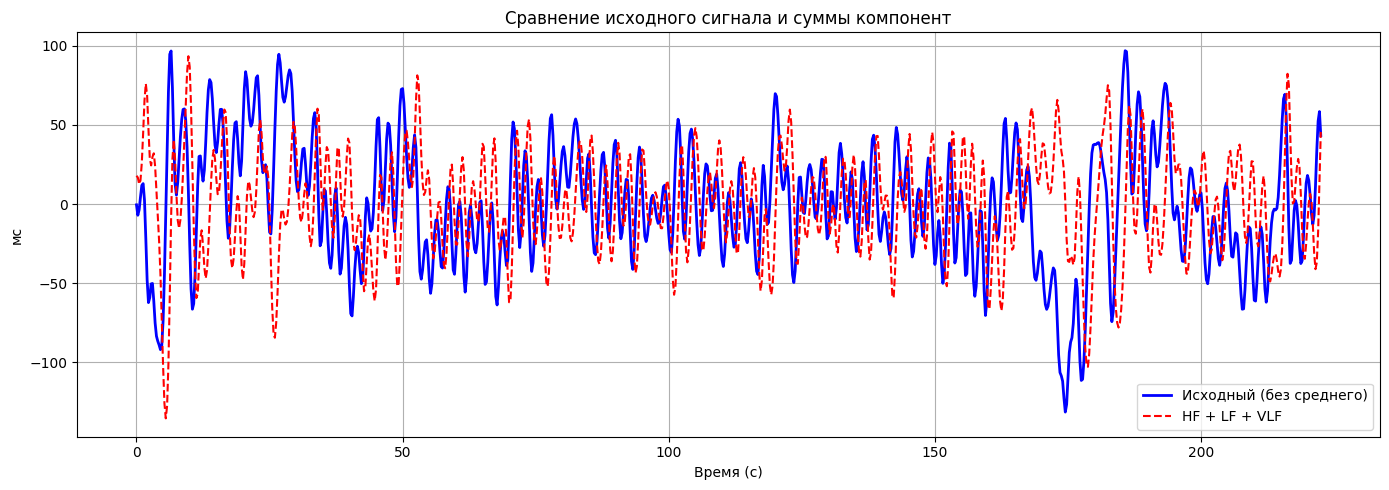

In [58]:
# 5
plt.figure(figsize=(14, 5))
plt.plot(t_u, sig - np.mean(sig), 'b', label='Исходный (без среднего)', linewidth=2)
plt.plot(t_u, HFt + LFt + VLFt, 'r--', label='HF + LF + VLF', linewidth=1.5)
plt.xlabel('Время (с)')
plt.ylabel('мс')
plt.title('Сравнение исходного сигнала и суммы компонент')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [59]:
def hrv_params(HFt, LFt, VLFt, label=""):
    HF  = np.sum(HFt**2)
    LF  = np.sum(LFt**2)
    VLF = np.sum(VLFt**2)
    TP  = HF + LF + VLF
    res = {
        "Wavelet/method": label,
        "HF (ms²)":   round(HF,  2),
        "LF (ms²)":   round(LF,  2),
        "VLF (ms²)":  round(VLF, 2),
        "TP (ms²)":   round(TP,  2),
        "HFn (%)":    round(HF/TP*100, 2),
        "LFn (%)":    round(LF/TP*100, 2),
        "VLFn (%)":   round(VLF/TP*100, 2),
        "LF/HF":      round(LF/HF, 4),
        "SDHF":       round(np.std(HFt), 4),
        "SDLF":       round(np.std(LFt), 4),
        "SDVLF":      round(np.std(VLFt), 4),
        "SDTP":       round(np.std(TPt), 4),
    }
    return res

In [60]:
results = []
r = hrv_params(HFt, LFt, VLFt, label=f"CWT ({WAVELET})")
results.append(r)

print(f"  параметры ВСР — вейвлет «{WAVELET}» \n")
for k, v in r.items():
    if k != "Вейвлет/метод":
        print(f"  {k:<15} {v}")

  параметры ВСР — вейвлет «gaus5» 

  Wavelet/method  CWT (gaus5)
  HF (ms²)        4.0
  LF (ms²)        17988.95
  VLF (ms²)       804387.42
  TP (ms²)        822380.37
  HFn (%)         0.0
  LFn (%)         2.19
  VLFn (%)        97.81
  LF/HF           4499.9964
  SDHF            0.067
  SDLF            4.4933
  SDVLF           30.0464
  SDTP            32.3723


In [33]:
# 6

In [ ]:
wavelets_compare = ["morl", "gaus5", "cmor1.5-1.0"]

for w in wavelets_compare:
    try:
        cw, fr, sc = compute_cwt(sig_centered, w, F_LOW, F_HIGH, D)
        h = band_reconstruct(cw, sc, fr, 0.15, 0.40)
        l = band_reconstruct(cw, sc, fr, 0.04, 0.15)
        v = band_reconstruct(cw, sc, fr, 0.003, 0.04)
        results.append(hrv_params(h, l, v, label=f"CWT ({w})"))
    except Exception as e:
        print(f"  Пропуск {w}: {e}")

In [40]:
def welch_band_power(signal, fs, f1, f2):
    f, psd = welch(signal, fs=fs, nperseg=min(256, len(signal)//2))
    idx = (f >= f1) & (f < f2)
    return np.trapezoid(psd[idx], f[idx])

In [41]:
HF_fft  = welch_band_power(sig_centered, D, 0.15, 0.40)
LF_fft  = welch_band_power(sig_centered, D, 0.04, 0.15)
VLF_fft = welch_band_power(sig_centered, D, 0.003, 0.04)
TP_fft  = HF_fft + LF_fft + VLF_fft

results.append({
    "Вейвлет/метод": "FFT (Welch)",
    "HF (мс²)":   round(HF_fft, 2),
    "LF (мс²)":   round(LF_fft, 2),
    "VLF (мс²)":  round(VLF_fft, 2),
    "TP (мс²)":   round(TP_fft, 2),
    "HFn (%)":    round(HF_fft/TP_fft*100, 2),
    "LFn (%)":    round(LF_fft/TP_fft*100, 2),
    "VLFn (%)":   round(VLF_fft/TP_fft*100, 2),
    "LF/HF":      round(LF_fft/HF_fft, 4),
    "SDHF":  "-", "SDLF": "-", "SDVLF": "-", "SDTP": "-"
})

In [46]:
df_results = pd.DataFrame(results).set_index("Вейвлет/метод")
print("\n" + df_results.to_string())



                  Wavelet/method  HF (ms²)  LF (ms²)  VLF (ms²)   TP (ms²)  HFn (%)  LFn (%)  VLFn (%)      LF/HF    SDHF    SDLF    SDVLF     SDTP  HF (мс²)  LF (мс²)  VLF (мс²)  TP (мс²)
Вейвлет/метод                                                                                                                                                                               
NaN                  CWT (gaus5)      4.00  17988.95  804387.42  822380.37     0.00     2.19     97.81  4499.9964   0.067  4.4933  30.0464  32.3723       NaN       NaN        NaN       NaN
NaN                   CWT (morl)     59.95   3735.91  311585.78  315381.64     0.02     1.18     98.80    62.3159  0.2594  2.0477  18.7002  32.3723       NaN       NaN        NaN       NaN
NaN                  CWT (gaus5)      4.00  17988.95  804387.42  822380.37     0.00     2.19     97.81  4499.9964   0.067  4.4933  30.0464  32.3723       NaN       NaN        NaN       NaN
NaN            CWT (cmor1.5-1.0)      9.67    331.82  

In [47]:
# 7

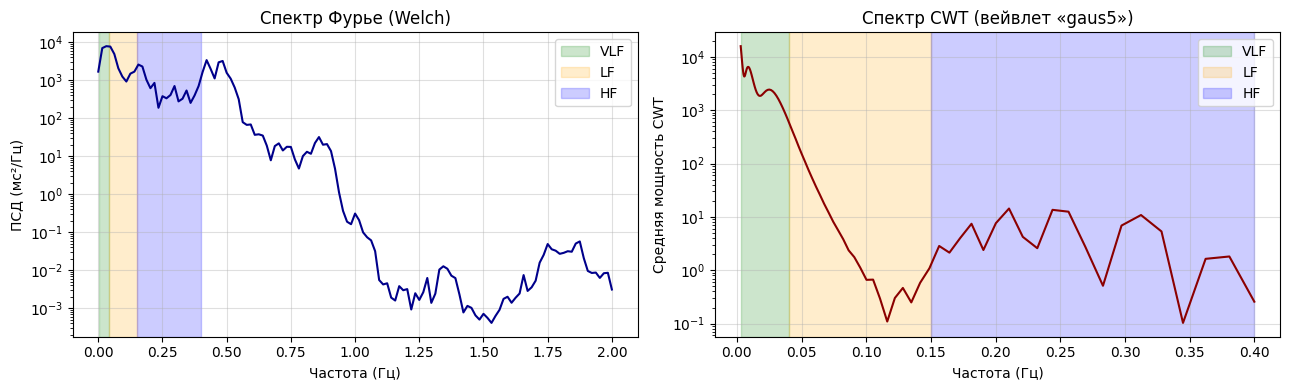

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Welch PSD
f_w, psd_w = welch(sig_centered, fs=D, nperseg=min(256, len(sig_centered)//2))
axes[0].semilogy(f_w, psd_w, color='darkblue')
axes[0].axvspan(0.003, 0.04,  alpha=0.2, color='green',  label='VLF')
axes[0].axvspan(0.04,  0.15,  alpha=0.2, color='orange', label='LF')
axes[0].axvspan(0.15,  0.4,   alpha=0.2, color='blue',   label='HF')
axes[0].set_xlabel("Частота (Гц)"); axes[0].set_ylabel("ПСД (мс²/Гц)")
axes[0].set_title("Спектр Фурье (Welch)"); axes[0].legend(); axes[0].grid(alpha=0.4)

# Средний спектр CWT (morl)
mean_power = np.mean(np.abs(cwt_matrix)**2, axis=1)
axes[1].semilogy(freqs, mean_power, color='darkred')
axes[1].axvspan(0.003, 0.04,  alpha=0.2, color='green',  label='VLF')
axes[1].axvspan(0.04,  0.15,  alpha=0.2, color='orange', label='LF')
axes[1].axvspan(0.15,  0.4,   alpha=0.2, color='blue',   label='HF')
axes[1].set_xlabel("Частота (Гц)"); axes[1].set_ylabel("Средняя мощность CWT")
axes[1].set_title(f"Спектр CWT (вейвлет «{WAVELET}»)"); axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.show()